### Import modules

In [1]:
# Standard imports
import pandas as pd
import sys 
import os
import seaborn as sns
import os
import shutil
import numpy as np
# Local imports
import analysis_functions

# Apply better style
analysis_functions.apply_heatmap_style()


### Plot tune scan

In [2]:
# Define study
STUDY_NAME = "HL19_tunescan"
COLLIDER = "base_collider"
PARQUET_PATH = f"../scans/{STUDY_NAME}/da.parquet"
CONF_MAD_PATH = f"../scans/{STUDY_NAME}/{COLLIDER}/config.yaml"
CONF_COLLIDER_PATH = f"../scans/{STUDY_NAME}/{COLLIDER}/xtrack_0016/config.yaml"

# Load dataframe
df = pd.read_parquet(f"../scans/{STUDY_NAME}/da.parquet")

# Round all numbers to 3 decimals
df = df.round(3)

# Keep only relevant collider
df = df.reset_index(level=1)
df = df[df["name base collider"] == COLLIDER]

df


name base collider  normalized amplitude in xy-plane_x  \
beam qx     qy                                                              
b1   62.305 60.309      base_collider                               4.000   
            60.310      base_collider                               4.031   
            60.311      base_collider                               4.250   
            60.312      base_collider                               4.031   
            60.313      base_collider                               4.625   
...                               ...                                 ...   
     62.323 60.328      base_collider                               4.000   
            60.329      base_collider                               4.000   
     62.324 60.328      base_collider                               4.000   
            60.329      base_collider                               4.000   
     62.325 60.329      base_collider                               4.000   

                    normalized amplitude in xy-plane_y      qx      qy  dqx  \
beam qx     qy                                                                
b1   62.305 60.309                               4.000  62.305  60.309   15   
            60.310                               4.031  62.305  60.310   15   
            60.311                               4.250  62.305  60.311   15   
            60.312                               4.031  62.305  60.312   15   
            60.313                               4.625  62.305  60.313   15   
...                                                ...     ...     ...  ...   
     62.323 60.328                               4.000  62.323  60.328   15   
            60.329                               4.000  62.323  60.329   15   
     62.324 60.328                               4.000  62.324  60.328   15   
            60.329                               4.000  62.324  60.329   15   
     62.325 60.329                               4.000  62.325  60.329   15   

                    dqy  i_bunch_b1  i_bunch_b2  i_oct_b1  i_oct_b2  \
beam qx     qy                                                        
b1   62.305 60.309   15        1963        1963      -235      -235   
            60.310   15        1963        1963      -235      -235   
            60.311   15        1963        1963      -235      -235   
            60.312   15        1963        1963      -235      -235   
            60.313   15        1963        1963      -235      -235   
...                 ...         ...         ...       ...       ...   
     62.323 60.328   15        1963        1963      -235      -235   
            60.329   15        1963        1963      -235      -235   
     62.324 60.328   15        1963        1963      -235      -235   
            60.329   15        1963        1963      -235      -235   
     62.325 60.329   15        1963        1963      -235      -235   

                   num_particles_per_bunch  crossing_angle  
beam qx     qy                                              
b1   62.305 60.309                  2.2e11           250.0  
            60.310                  2.2e11           250.0  
            60.311                  2.2e11           250.0  
            60.312                  2.2e11           250.0  
            60.313                  2.2e11           250.0  
...                                    ...             ...  
     62.323 60.328                  2.2e11           250.0  
            60.329                  2.2e11           250.0  
     62.324 60.328                  2.2e11           250.0  
            60.329                  2.2e11           250.0  
     62.325 60.329                  2.2e11           250.0  

[211 rows x 13 columns]

In [3]:
#normalised_amplitude_xy_plane = np.sqrt(df["normalized amplitude in xy-plane_x"]**2 + df["normalized amplitude in xy-plane_y"]**2)

In [4]:
#df.insert(4, "normalized amplitude in xy-plane", normalised_amplitude_xy_plane)

In [5]:
# Reshape for plotting
df_to_plot = df.pivot(index="qy", columns="qx", values="normalized amplitude in xy-plane_x")
df_to_plot

qx,62.305,62.306,62.307,62.308,62.309,62.310,62.311,62.312,62.313,62.314,...,62.316,62.317,62.318,62.319,62.320,62.321,62.322,62.323,62.324,62.325
qy,,,,,,,,,,,,,,,,,,,,,
60.309,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.310,4.031,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.311,4.250,4.062,4.031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.312,4.031,4.094,4.062,4.062,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.313,4.625,4.250,4.000,4.000,4.188,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.314,4.188,4.125,4.031,4.000,4.094,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.315,4.406,4.031,4.062,4.000,4.125,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.316,4.719,4.031,4.125,4.000,NaN,5.188,5.281,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.317,4.625,4.031,4.094,4.000,4.062,5.438,5.469,NaN,5.562,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Replace NaNs above the upper diagonal with 8
fill_nan = True

if fill_nan:
    for qx in df_to_plot.columns:
        for qy in df_to_plot.index:
            if qy >= qx - 2 + 0.004:
                if pd.isna(df_to_plot.loc[qy, qx]):
                    df_to_plot.loc[qy, qx] = 8

Luminosity not found in config, setting to None


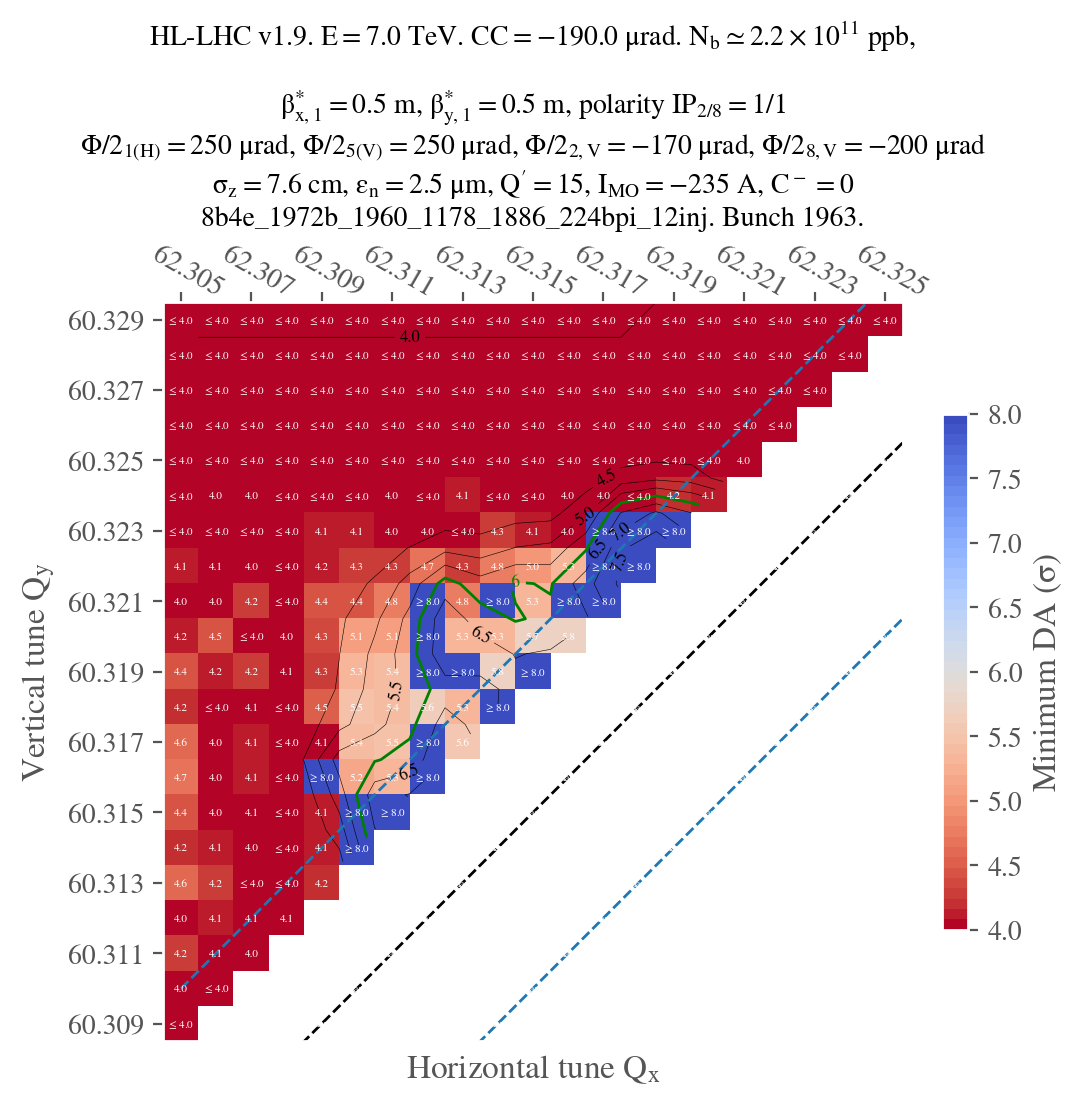

In [9]:
# Load configuration files
conf_mad = analysis_functions.load_config(CONF_MAD_PATH)
conf_collider = analysis_functions.load_config(CONF_COLLIDER_PATH)["config_collider"]
analysis_functions.plot_heatmap(
    df_to_plot,
    f'{STUDY_NAME}_{COLLIDER}',
    link=None,
    plot_contours=True,
    conf_mad=conf_mad,
    conf_collider=conf_collider,
    type_crossing="flathv",
    betx=0.5,
    bety=0.5,
    Nb=True,
    green_contour=6.,
    extended_diagonal=False,
    vmin=4.,
    vmax=8.0,
    CC = True,
)
#! Verified

In [8]:
# Reshape for plotting
df_to_plot = df.pivot(index="qy", columns="qx", values="normalized amplitude in xy-plane_y")
df_to_plot

qx,62.305,62.306,62.307,62.308,62.309,62.310,62.311,62.312,62.313,62.314,...,62.316,62.317,62.318,62.319,62.320,62.321,62.322,62.323,62.324,62.325
qy,,,,,,,,,,,,,,,,,,,,,
60.309,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.310,4.031,4.031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.311,4.250,4.188,4.031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.312,4.125,4.094,4.062,4.062,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.313,4.625,4.250,4.031,4.000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.314,4.438,NaN,4.031,4.000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.315,4.406,4.031,4.062,4.000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.316,4.719,NaN,4.125,4.094,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60.317,4.625,4.031,NaN,NaN,NaN,NaN,NaN,NaN,5.562,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Replace NaNs above the upper diagonal with 8
for qx in df_to_plot.columns:
    for qy in df_to_plot.index:
        if qy >= qx - 2 + 0.004:
            if pd.isna(df_to_plot.loc[qy, qx]):
                df_to_plot.loc[qy, qx] = 8

Luminosity not found in config, setting to None


FileNotFoundError: [Errno 2] No such file or directory: 'plots/output_HL19_tunescan_base_collider.pdf'

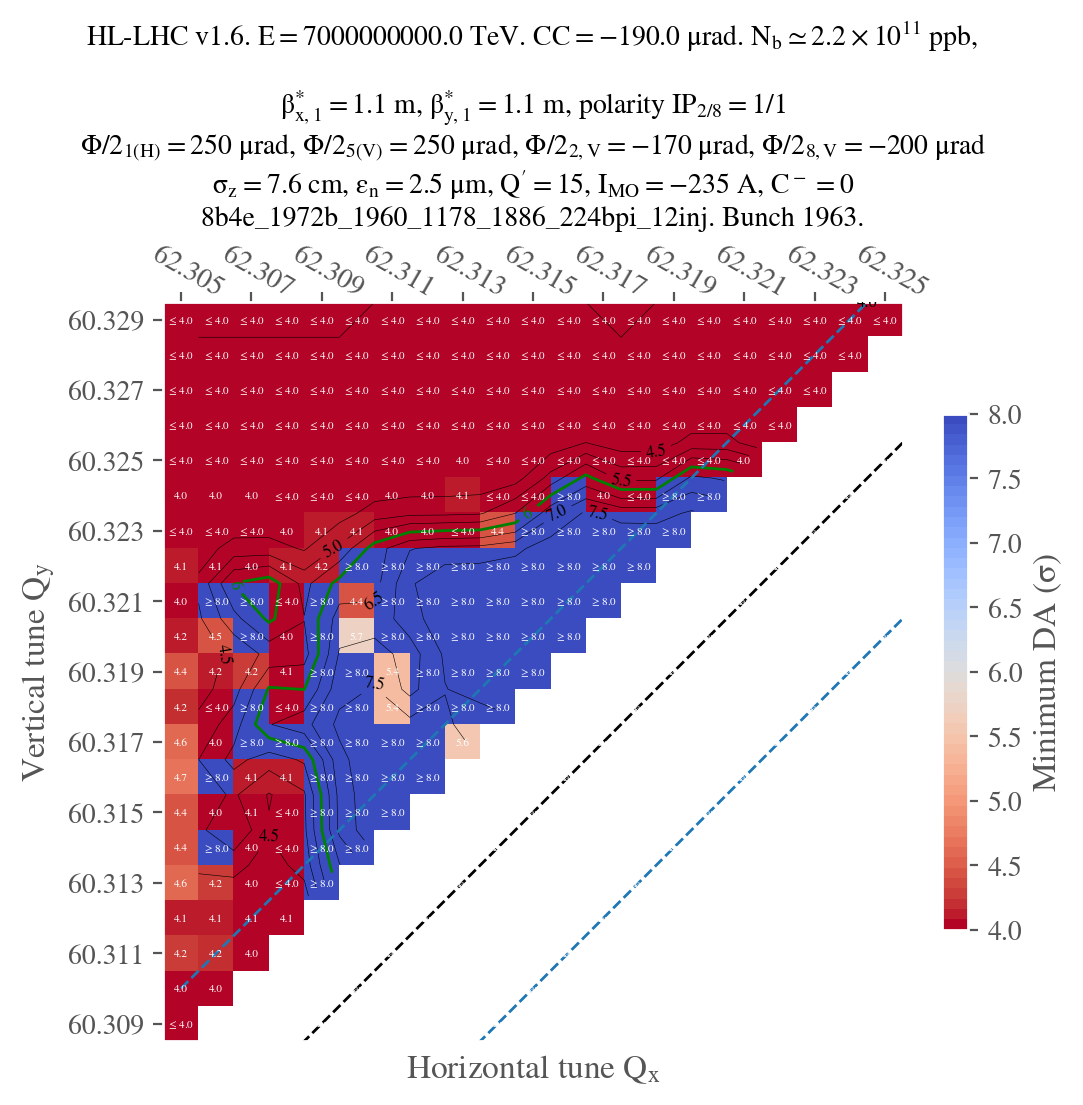

In [10]:
# Load configuration files
conf_mad = analysis_functions.load_config(CONF_MAD_PATH)
conf_collider = analysis_functions.load_config(CONF_COLLIDER_PATH)["config_collider"]
analysis_functions.plot_heatmap(
    df_to_plot,
    f'{STUDY_NAME}_{COLLIDER}',
    link=None,
    plot_contours=True,
    conf_mad=conf_mad,
    conf_collider=conf_collider,
    type_crossing="flathv",
    betx=1.1,
    bety=1.1,
    Nb=True,
    green_contour=6.,
    extended_diagonal=False,
    vmin=4.,
    vmax=8.0,
    CC = True,
)
#! Verified

In [11]:
print(df['normalized amplitude in xy-plane_x'])

beam  qx      qy    
b1    62.305  60.309    4.000
              60.310    4.031
              60.311    4.250
              60.312    4.125
              60.313    4.625
                        ...  
      62.323  60.328    4.000
              60.329    4.000
      62.324  60.328    4.000
              60.329    4.000
      62.325  60.329    4.000
Name: normalized amplitude in xy-plane_x, Length: 166, dtype: float64


In [12]:
print(df['normalized amplitude in xy-plane_y'])

beam  qx      qy    
b1    62.305  60.309    4.000
              60.310    4.031
              60.311    4.250
              60.312    4.125
              60.313    4.625
                        ...  
      62.323  60.328    4.000
              60.329    4.000
      62.324  60.328    4.000
              60.329    4.000
      62.325  60.329    4.000
Name: normalized amplitude in xy-plane_y, Length: 166, dtype: float64
